Problem Statement : Customer churn prediction refers to the process of identifying customers who are likely to stop using a product or service in the near future. It is a valuable predictive analytics technique used by businesses to forecast customer behavior and take proactive measures to retain customers.

Objective : objective of this project is to predict wather customer is about to churn or not.

Kaggle Dataset Link : https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import pickle
from matplotlib import pyplot as plt
import scipy
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest
from collections import Counter
from imblearn.combine import SMOTEENN
plt.style.use('default')
import warnings
warnings.filterwarnings("ignore")

In [1]:
#import the dataset
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

NameError: name 'pd' is not defined

In [ ]:
#print concise summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
#check for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
#check for duplicate records
df[df.duplicated()].shape[0]

0

In [6]:
#check datatype
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
#since customerId is not required for prediction so drop it
df.drop('customerID',axis=1,inplace=True)

In [8]:
#since total changes is having numerical value but dtype is object to change it into numeric
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [9]:
#print last 5 records of the  dataset
df.tail(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes
7042,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No


# Exploratory Data Analysis :

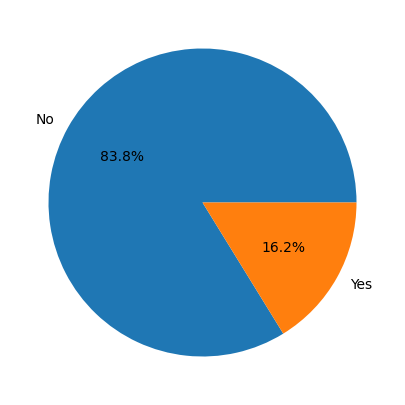

In [10]:
#pie chart to count senior citizen
plt.figure(figsize=(10,5))
plt.pie(df["SeniorCitizen"].value_counts(),autopct="%.1f%%",labels=["No","Yes"])
plt.show()

as we can see 83.8 % of the customers are senior citizen and only 16.2% are adult customer.

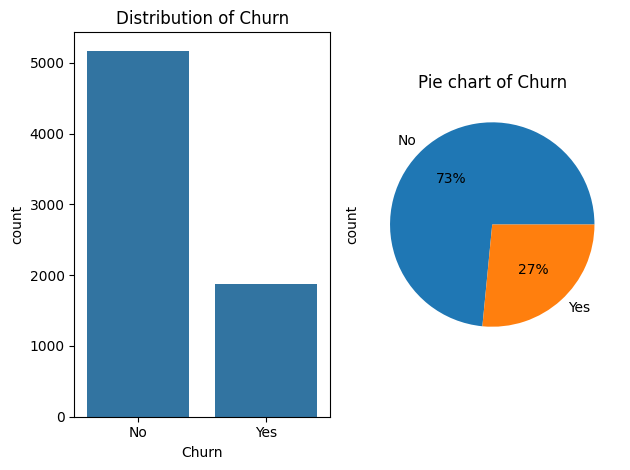

In [11]:
#check the distibution of churn class
plt.subplot(121)
sns.countplot(data=df,x="Churn")
plt.title("Distribution of Churn")
plt.subplot(122)
df['Churn'].value_counts().plot(kind='pie',autopct="%1.f%%",labels=['No','Yes'])
plt.title('Pie chart of Churn')
plt.tight_layout()
plt.show()

Since our dataset is highly imbalance we need to balance before fitting it into model

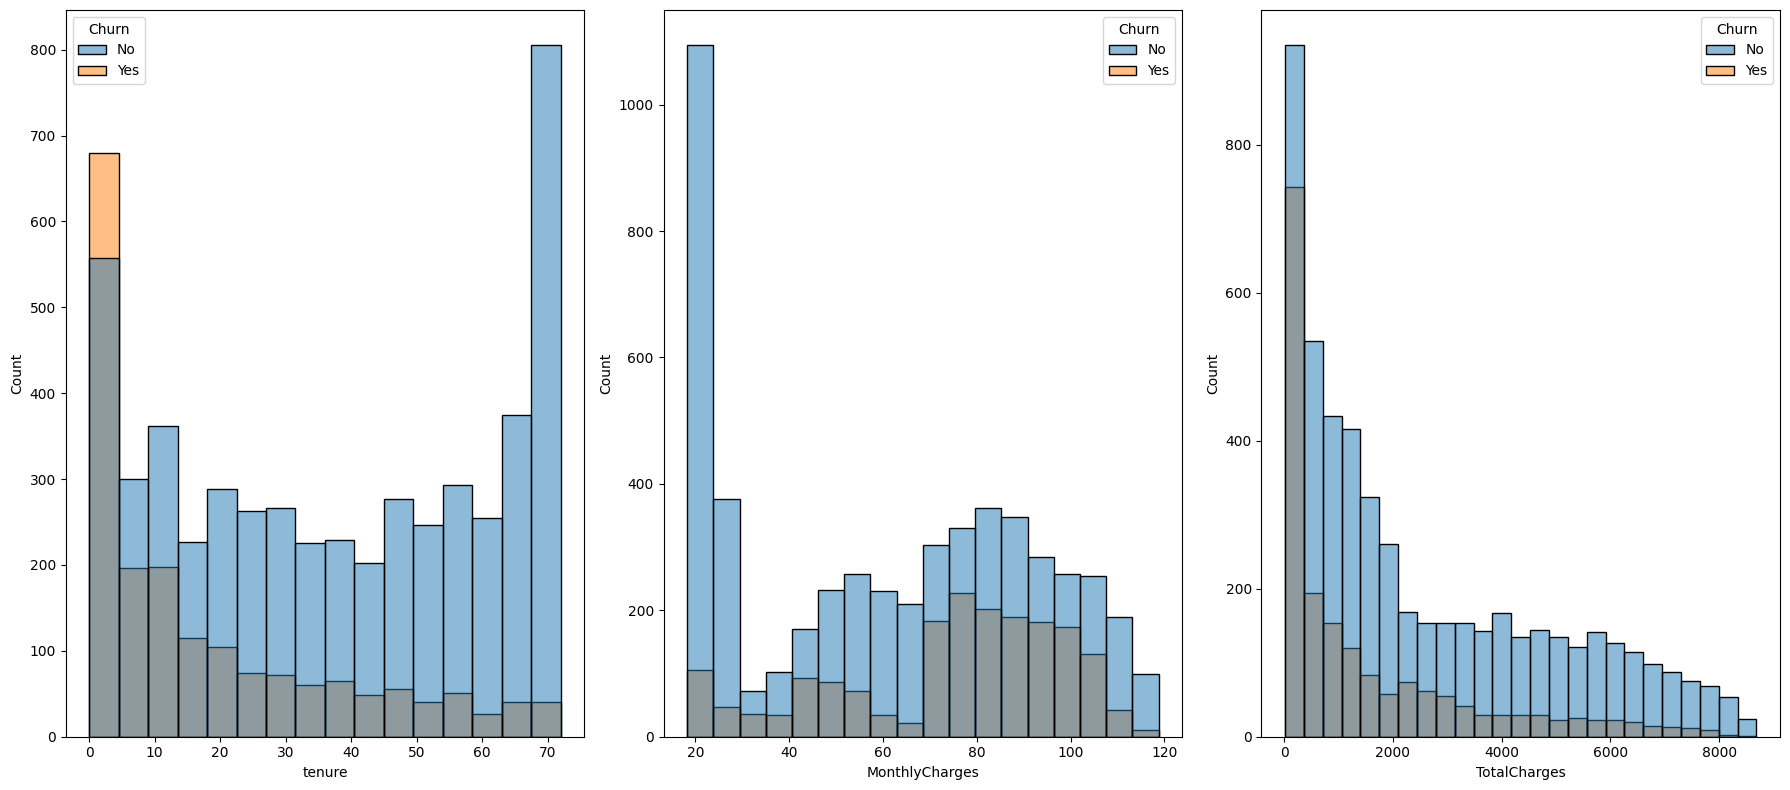

In [12]:
#plot numerical features with histogram
fig,axs=plt.subplots(nrows=1,ncols=3,figsize=(18,8))
axes=axs.flatten()
num_columns=['tenure', 'MonthlyCharges', 'TotalCharges']
for i,col in enumerate(num_columns):
  if(col!='SeniorCitizen'):
    sns.histplot(x=col,data=df,hue='Churn',ax=axes[i])
fig.tight_layout()
plt.show()

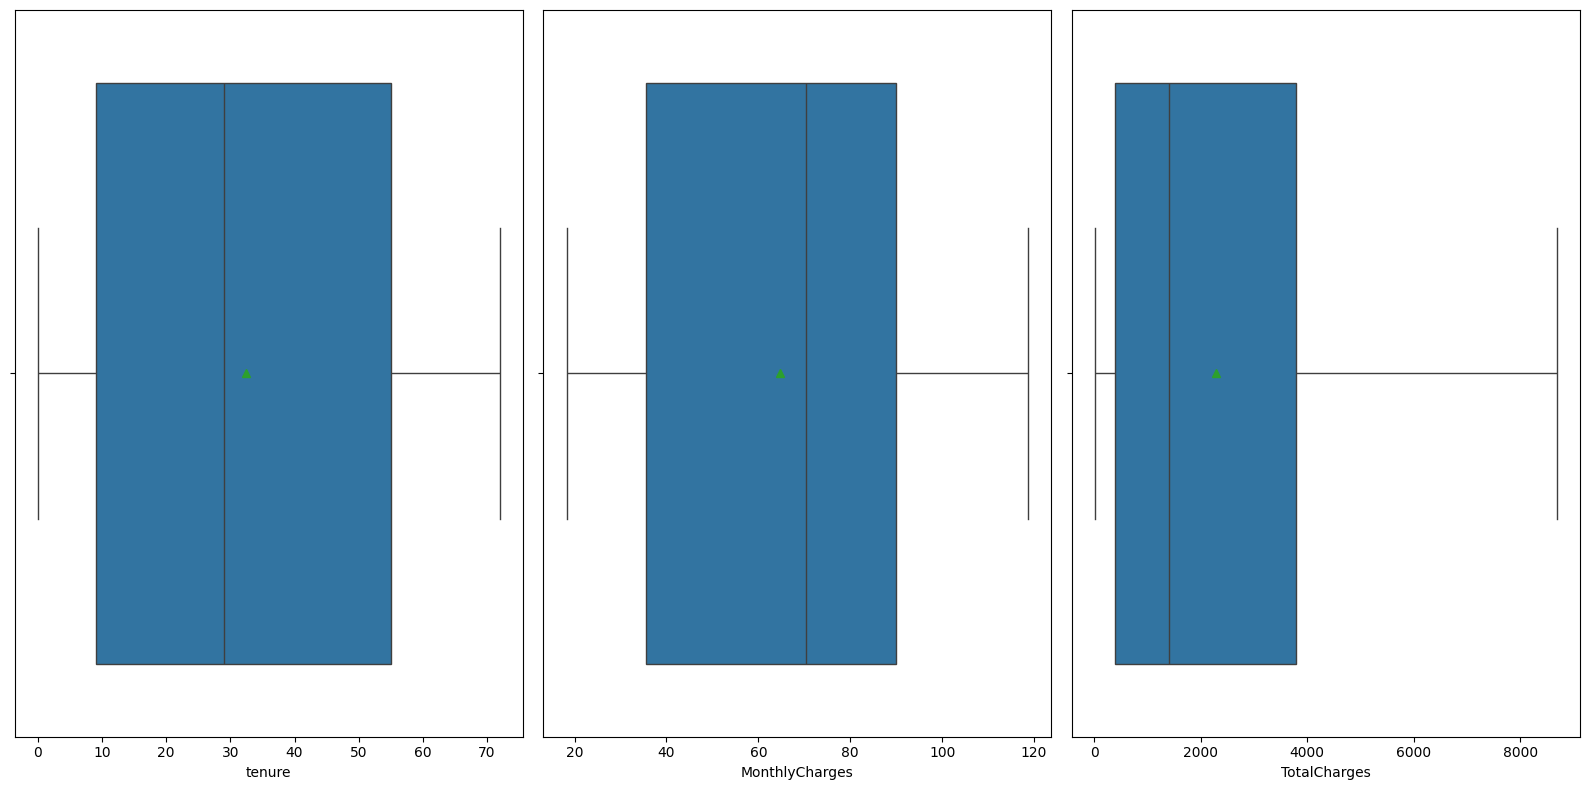

In [13]:
#plot numerical features with boxplot
fig,axs=plt.subplots(nrows=1,ncols=3,figsize=(16,8))
axes=axs.flatten()
num_columns=['tenure', 'MonthlyCharges', 'TotalCharges']
for i,col in enumerate(num_columns):
  if(col!='SeniorCitizen'):
    sns.boxplot(x=col,data=df,showmeans=True,ax=axes[i])
fig.tight_layout()
plt.show()

after plotting histogram and boxplot we found that there is no outlier present in numeric dataset so we don't need to do any kind of outlier treatment.

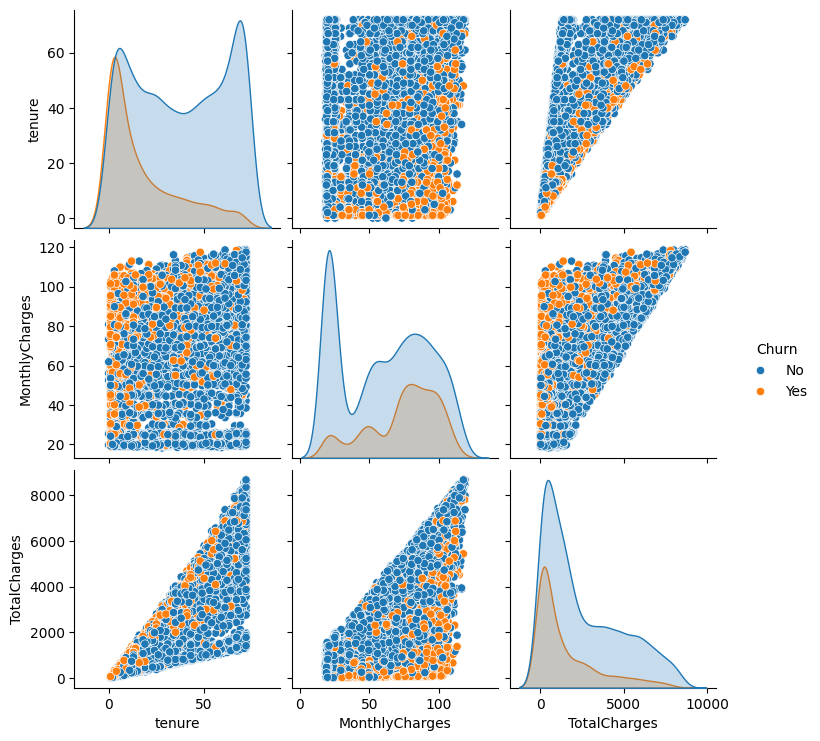

In [14]:
sns.pairplot(df.drop(columns="SeniorCitizen"),hue="Churn",kind="scatter")
plt.show()

# Univariate Analysis

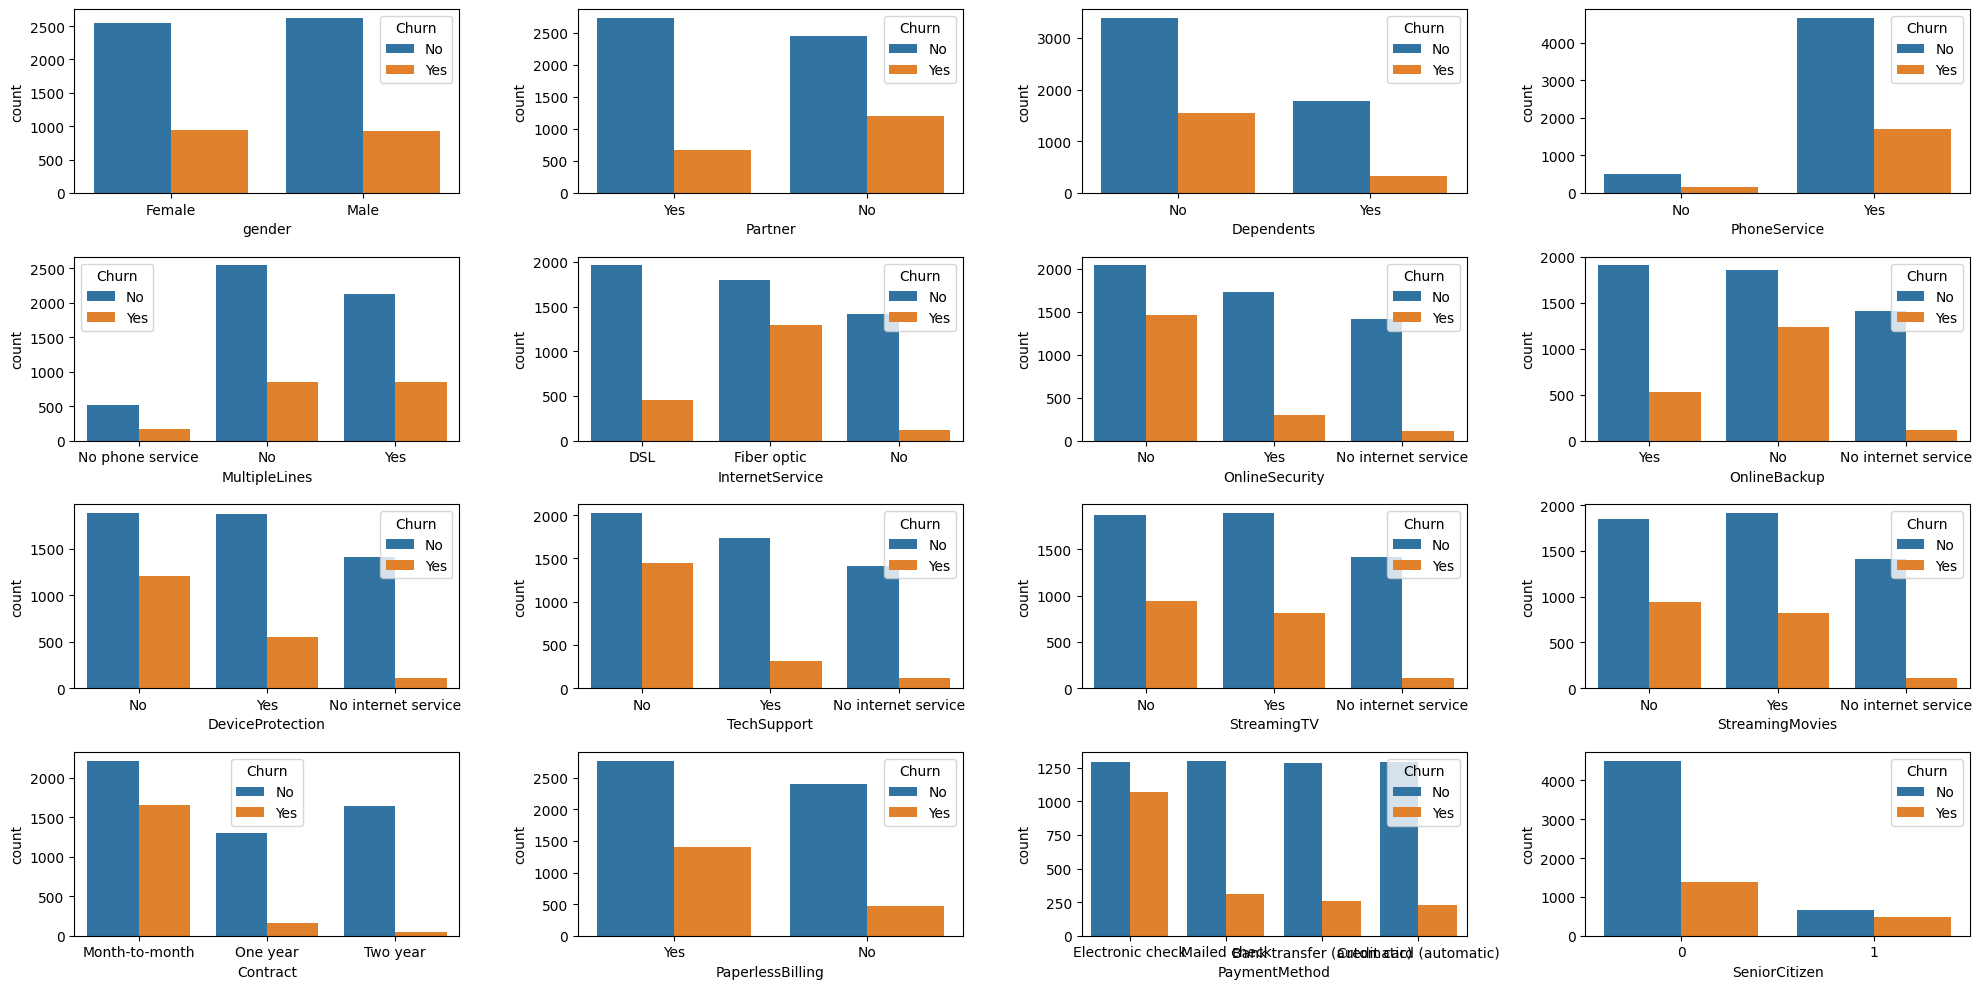

In [15]:
#plot cateogrical features :
cat_features=list(df.select_dtypes(include='object').columns)
cat_features.remove('Churn')
cat_features.append('SeniorCitizen')

fig,axs=plt.subplots(nrows=4,ncols=4,figsize=(20,10))
axes=axs.flatten()
for i,col in enumerate(cat_features):
    sns.countplot(x=col,hue="Churn",data=df,ax=axes[i])
#adjust spacing between subplots
fig.tight_layout()
plt.show()

# Data Cleaning

In [16]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
#check for null values
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [18]:
df["TotalCharges"].fillna(df["TotalCharges"].mean(),inplace=True)

In [19]:
df.isnull().sum().sum()

0

In [20]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [21]:
# identifying columns with object data type
object_columns = df.select_dtypes(include="object").columns.drop("Churn")

In [22]:
object_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [23]:
# initialize a dictionary to save the encoders
encoders = {}

# apply label encoding and store the encoders
for column in object_columns:
  label_encoder = LabelEncoder()
  df[column] = label_encoder.fit_transform(df[column])
  encoders[column] = label_encoder


# save the encoders to a pickle file
with open("encoders.pkl", "wb") as f:  # 'wb' is write binary mode
    pickle.dump(encoders, f)

In [24]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [25]:
from sklearn.preprocessing import StandardScaler
# Fit scaler on numerical features
num_features = ["MonthlyCharges", "TotalCharges", "tenure"]
scaler = StandardScaler()
scaler.fit(df[num_features]) 
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [26]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,No
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,No
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,Yes
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,No
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,Yes


In [27]:
df.dtypes

gender                int32
SeniorCitizen         int64
Partner               int32
Dependents            int32
tenure                int64
PhoneService          int32
MultipleLines         int32
InternetService       int32
OnlineSecurity        int32
OnlineBackup          int32
DeviceProtection      int32
TechSupport           int32
StreamingTV           int32
StreamingMovies       int32
Contract              int32
PaperlessBilling      int32
PaymentMethod         int32
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

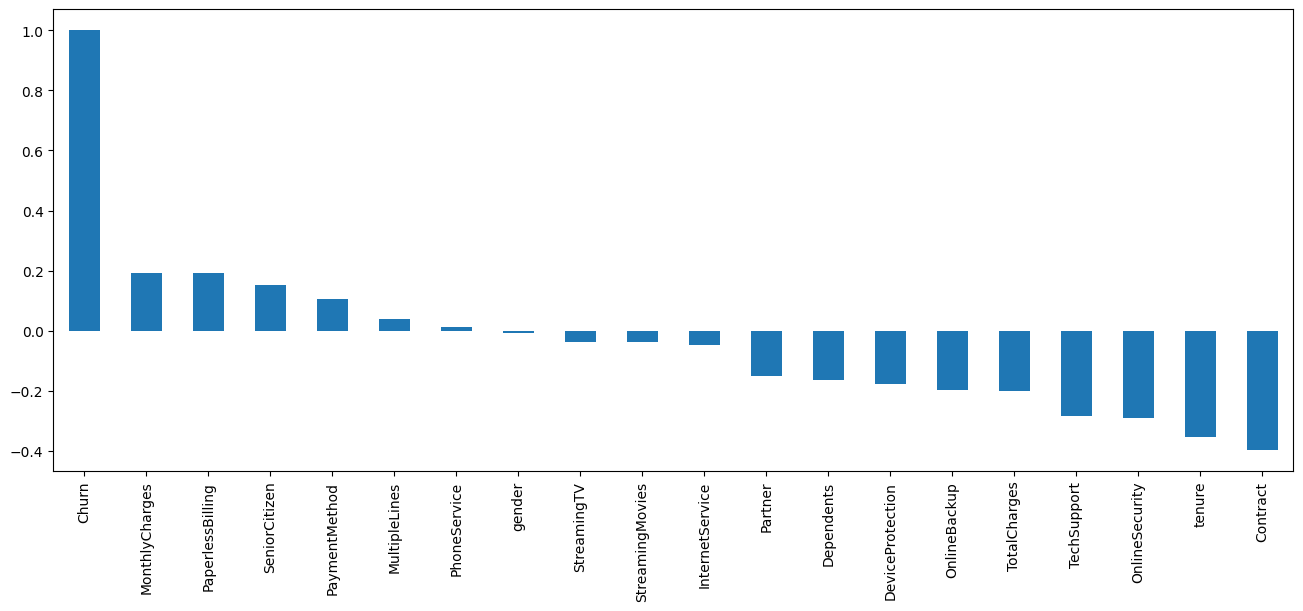

In [28]:
#get correlation of churn with other variables
# Convert 'Churn' column to numeric (0 = No, 1 = Yes)
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# Now compute correlation
plt.figure(figsize=(16,6))
df.corr()["Churn"].sort_values(ascending=False).plot(kind="bar")
plt.show()

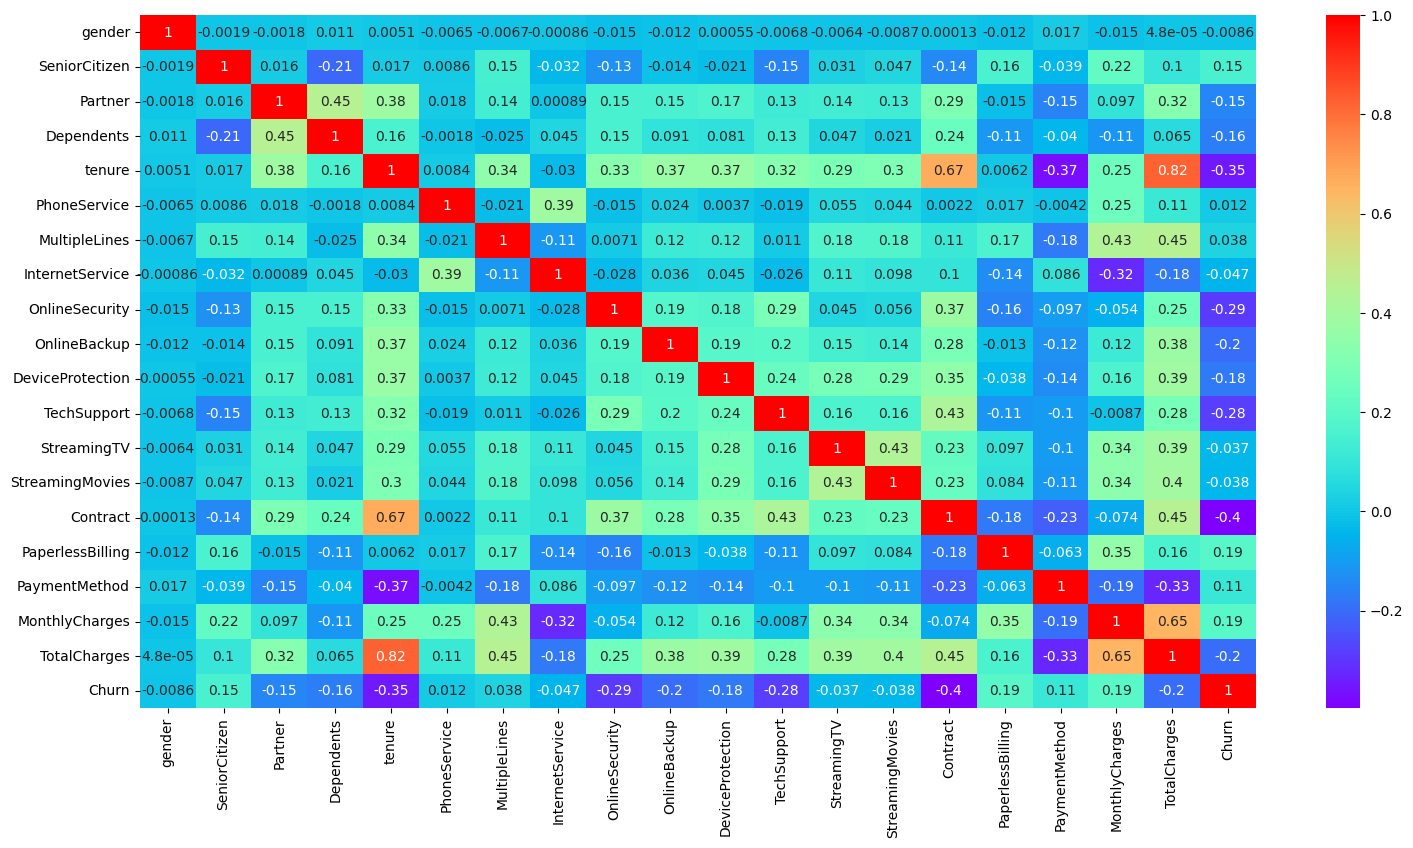

In [29]:
plt.figure(figsize=(18,9))
sns.heatmap(df.corr(),annot=True,cmap="rainbow")
plt.show()

since we are using ensemble methods for model building so there is no need of feature scaling as its prediction is based on creating multiple decision tree

In [30]:
#seperating independent variables and target variable
x=df.drop("Churn",axis=1)
y=df["Churn"]

In [31]:
x.shape

(7043, 19)

In [32]:
select_feature=SelectKBest(k=10) #no of features to be select
select_feature.fit(x,y)

SelectKBest()

In [33]:
#Top 15 high correlated features
select_feature.get_feature_names_out()

array(['Dependents', 'tenure', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'Contract', 'PaperlessBilling',
       'MonthlyCharges', 'TotalCharges'], dtype=object)

In [34]:
x=x[select_feature.get_feature_names_out()]

In [35]:
x.shape

(7043, 10)

In [36]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [37]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((5634, 10), (5634,), (1409, 10), (1409,))

In [38]:
#its imbalance dataset
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [39]:
def evaluate_model_performance(model,test_data):
    prediction=model.predict(test_data)
    #print("Training Accurary : ",model.score(x_train,y_train))
    print("Validation Accurary : {:.4f} %".format(accuracy_score(y_test,prediction)))
    print("Precision Score : {:.4f} %".format(precision_score(y_test,prediction)))
    print("Recall Score : {:.4f} %".format(recall_score(y_test,prediction)))
    print("F1 Score : {:.4f} %".format(f1_score(y_test,prediction)))
    print(classification_report(y_test,prediction))

In [40]:
#Random Forest Model without balancing dataset and without hyper paramter tuning
rand_forest=RandomForestClassifier()
rand_forest.fit(x_train,y_train)

RandomForestClassifier()

In [41]:
#measure the performance of random forest model
evaluate_model_performance(rand_forest,x_test)

Validation Accurary : 0.7878 %
Precision Score : 0.6350 %
Recall Score : 0.4665 %
F1 Score : 0.5379 %
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1036
           1       0.64      0.47      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.79      0.78      1409



In [42]:
#Decision Tree Model without balancing dataset and without hyper paramter tuning
deci_tree=DecisionTreeClassifier()
deci_tree.fit(x_train,y_train)

DecisionTreeClassifier()

In [43]:
#measure the performance of random forest model
evaluate_model_performance(deci_tree,x_test)

Validation Accurary : 0.7232 %
Precision Score : 0.4777 %
Recall Score : 0.4879 %
F1 Score : 0.4828 %
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1036
           1       0.48      0.49      0.48       373

    accuracy                           0.72      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.72      0.72      1409



In [44]:
#GradientBoostingClassifier without balancing dataset and without hyper paramter tuning
gbc_model=GradientBoostingClassifier( )
gbc_model.fit(x_train,y_train)

GradientBoostingClassifier()

In [45]:
#measure the performance of GradientBoostingClassifier
evaluate_model_performance(gbc_model,x_test)

Validation Accurary : 0.8055 %
Precision Score : 0.6656 %
Recall Score : 0.5335 %
F1 Score : 0.5923 %
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.67      0.53      0.59       373

    accuracy                           0.81      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



as we can see our model is not performing up to the mark because of imbalance nature of dataset so we will balance it to reduce TN,FN and increase TP,FP

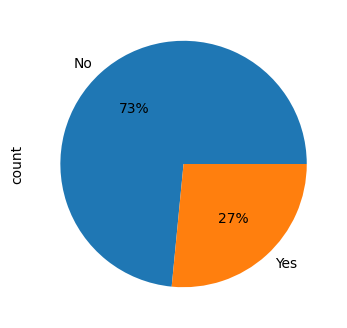

In [46]:
plt.figure(figsize=(8,4))
y.value_counts().plot(kind="pie",autopct="%1.f%%",labels=['No','Yes'])
plt.show()

we have 2 classes class 0 and class 1.
class 0 - majority class
class 1 -minority class

In [47]:
from imblearn.over_sampling import SMOTE

In [65]:
smote= SMOTEENN(random_state=42)
x_smote,y_smote=smote.fit_resample(x_train,y_train)

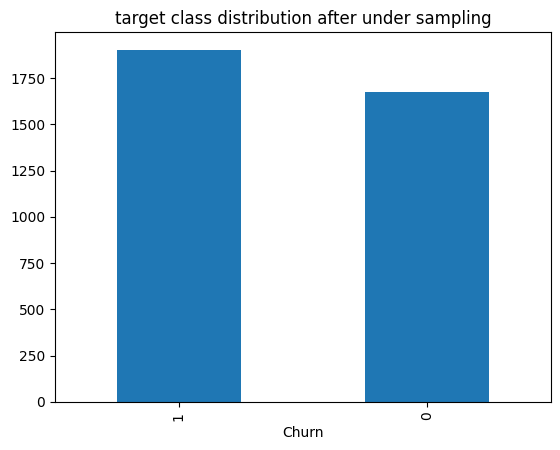

In [66]:
y_smote.value_counts().plot(kind="bar")
plt.title("target class distribution after under sampling")
plt.show()

In [67]:
y_smote.value_counts()

Churn
1    1903
0    1677
Name: count, dtype: int64

In [68]:
#now split training and validation set using balanced dataset
x_train,x_test,y_train,y_test=train_test_split(x_smote,y_smote,test_size=0.2,random_state=42)

In [69]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((2864, 10), (2864,), (716, 10), (716,))

In [70]:
param_grid_rf = {
    'max_depth': range(9, 21),         # Range for max-depth (9 to 20 inclusive)
    'n_estimators': range(14, 21),    # Range for n-estimators (14 to 20 inclusive)
    'min_samples_split': [5],         # Minimum number of samples required to split a node
    'min_samples_leaf': [2],          # Minimum number of samples required in a leaf
    'max_features': ['sqrt'],         # Number of features to consider
    'bootstrap': [True]               # Sampling with replacement
}

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Configure GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    scoring='roc_auc',  # Optimization based on AUC score
    cv=5,               # 5-fold cross-validation
    verbose=1,
    n_jobs=-1           # Use all available cores
)

# Fit the model on balanced data
grid_search_rf.fit(x_train, y_train)

Fitting 5 folds for each of 84 candidates, totalling 420 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': range(9, 21),
                         'max_features': ['sqrt'], 'min_samples_leaf': [2],
                         'min_samples_split': [5],
                         'n_estimators': range(14, 21)},
             scoring='roc_auc', verbose=1)

In [71]:
# Best parameters found
best_params_rf = grid_search_rf.best_params_
print(f"Best Random Forest Parameters: {best_params_rf}")

# Best model
rf_model_balanced = grid_search_rf.best_estimator_

Best Random Forest Parameters: {'bootstrap': True, 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 19}


In [72]:
#evaluate Random Forest Classifier
evaluate_model_performance(rf_model_balanced,x_test)

Validation Accurary : 0.9399 %
Precision Score : 0.9200 %
Recall Score : 0.9637 %
F1 Score : 0.9413 %
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       358
           1       0.92      0.96      0.94       358

    accuracy                           0.94       716
   macro avg       0.94      0.94      0.94       716
weighted avg       0.94      0.94      0.94       716



In [73]:
# Scores training and test
train_score = rf_model_balanced.score(x_train, y_train)
test_score = rf_model_balanced.score(x_test, y_test)
print(f"Train score = {train_score:.4f}")
print(f"Test score = {test_score:.4f}")

Train score = 0.9815
Test score = 0.9399


In [74]:
param_grid2 = {
    'max_depth': [2, 4, 6, 8, 10],
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'random_state': [27, 42, 43]
}

In [75]:
decision_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=param_grid2,  # Fixed the parameter name
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1  # Enables parallel processing for faster execution
)

In [76]:
decision_tree.fit(x_train, y_train)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 8, 10],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20],
                         'random_state': [27, 42, 43],
                         'splitter': ['best', 'random']},
             scoring='accuracy', verbose=1)

In [77]:
#Get decision tree model with best param from GridSearchCV
dt_final_model=decision_tree.best_estimator_

In [78]:
#evaluate decision tree Classifier
evaluate_model_performance(dt_final_model,x_test)

Validation Accurary : 0.9190 %
Precision Score : 0.9076 %
Recall Score : 0.9330 %
F1 Score : 0.9201 %
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       358
           1       0.91      0.93      0.92       358

    accuracy                           0.92       716
   macro avg       0.92      0.92      0.92       716
weighted avg       0.92      0.92      0.92       716



In [79]:
# Scores training and test
train_score = dt_final_model.score(x_train, y_train)
test_score = dt_final_model.score(x_test, y_test)
print(f"Train score = {train_score:.4f}")
print(f"Test score = {test_score:.4f}")

Train score = 0.9578
Test score = 0.9190


In [80]:
param_grid3 = {'n_estimators': [200, 250, 300, 350, 400],  # More trees might help
    'criterion': ['friedman_mse', 'squared_error'],  # Stick to these; 'mse' and 'mae' are deprecated/less relevant
    'max_depth': [6, 8, 10, 12],  # Deeper trees for complexity, but watch overfitting
    'learning_rate': [0.05, 0.1, 0.15, 0.2],  # Fine-tune around 0.1
    'loss': ['deviance', 'exponential'],  # Both are valid for classification
    'min_samples_split': [2, 5, 10],  # Add regularization
    'min_samples_leaf': [1, 2, 4],  # Add regularization
    'subsample': [0.8, 0.9, 1.0]
              }

In [81]:
gbm_model=RandomizedSearchCV(estimator=GradientBoostingClassifier(random_state=42) , param_distributions=param_grid3,n_iter=20,verbose=1,scoring='f1')
gbm_model.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(estimator=GradientBoostingClassifier(random_state=42),
                   n_iter=20,
                   param_distributions={'criterion': ['friedman_mse',
                                                      'squared_error'],
                                        'learning_rate': [0.05, 0.1, 0.15, 0.2],
                                        'loss': ['deviance', 'exponential'],
                                        'max_depth': [6, 8, 10, 12],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 250, 300, 350,
                                                         400],
                                        'subsample': [0.8, 0.9, 1.0]},
                   scoring='f1', verbose=1)

In [82]:
gbm_model.best_params_

{'subsample': 0.8,
 'n_estimators': 250,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_depth': 10,
 'loss': 'exponential',
 'learning_rate': 0.1,
 'criterion': 'friedman_mse'}

In [83]:
gb_final_model=gbm_model.best_estimator_

In [84]:
#evaluate final GradientBoostingClassifier Performance
evaluate_model_performance(gb_final_model,x_test)

Validation Accurary : 0.9483 %
Precision Score : 0.9280 %
Recall Score : 0.9721 %
F1 Score : 0.9495 %
              precision    recall  f1-score   support

           0       0.97      0.92      0.95       358
           1       0.93      0.97      0.95       358

    accuracy                           0.95       716
   macro avg       0.95      0.95      0.95       716
weighted avg       0.95      0.95      0.95       716



Save Final Model Integration with application

Conclusion : after balancing the dataset using smootenn and hyper paramter tuning model performance has increase and the highest f1 score we are getting is 97%.

In [85]:
# save the trained model as a pickle file
model_data = {"model":gb_final_model , "features_names": x.columns.tolist()}


with open("customer_churn_model.pkl", "wb") as f:
  pickle.dump(model_data, f)

In [86]:
# load teh saved model and the feature names

with open("customer_churn_model.pkl", "rb") as f:
  model_data = pickle.load(f)

loaded_model = model_data["model"]
feature_names = model_data["features_names"]

In [87]:
print(loaded_model)

GradientBoostingClassifier(loss='exponential', max_depth=10, min_samples_leaf=2,
                           min_samples_split=5, n_estimators=250,
                           random_state=42, subsample=0.8)


In [88]:
print(feature_names)

['Dependents', 'tenure', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges']


In [89]:
pip install lifelines

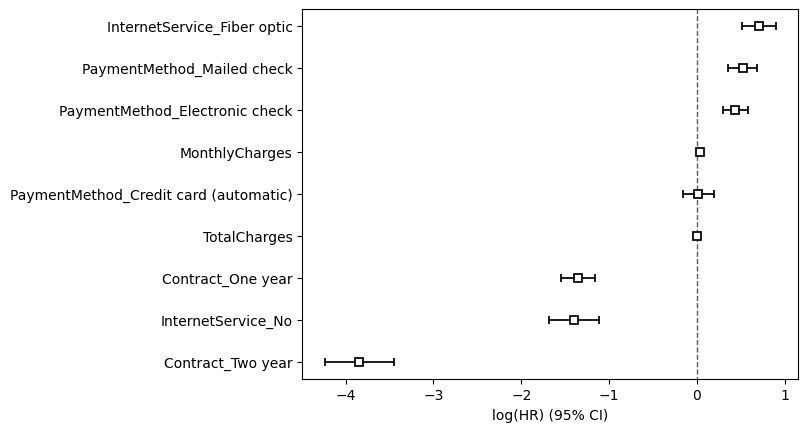

In [90]:
from lifelines import CoxPHFitter

# Assuming 'Churn' column is now numeric (0/1)

# Reload the original DataFrame to ensure 'tenure' column exists
original_df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
original_df.drop('customerID',axis=1,inplace=True)
original_df['TotalCharges']=pd.to_numeric(original_df['TotalCharges'],errors='coerce')
original_df["TotalCharges"].fillna(original_df["TotalCharges"].mean(),inplace=True)
original_df["Churn"] = original_df["Churn"].map({"No": 0, "Yes": 1})


# Create a new DataFrame with necessary columns for CoxPHFitter
cox_df = pd.DataFrame()
cox_df['event'] = y  # Using the target variable 'y' which contains 'Churn' data
cox_df['duration'] = original_df['tenure'] # Accessing 'tenure' from original_df

# Selecting relevant covariates
covariates = ['MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod', 'InternetService']

# Adding covariates to the new DataFrame
for covariate in covariates:
    cox_df[covariate] = original_df[covariate]  # Accessing covariates from original_df

# Selecting the desired columns for the Cox model
cox_df = cox_df[['duration', 'event'] + covariates].dropna()

# Convert categorical variables to numerical using one-hot encoding
cox_df = pd.get_dummies(cox_df, drop_first=True)

# Fit the Cox model
cox_model = CoxPHFitter()
cox_model.fit(cox_df, duration_col='duration', event_col='event')

# Plot the coefficients
cox_model.plot()
plt.show()

In [1]:
import pickle
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Define the input data
input_data = {
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'Yes',
    'tenure': 10,
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'Yes',
    'TechSupport': 'Yes',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'No',
    'PaymentMethod': 'Credit card (automatic)',
    'MonthlyCharges': 55.2,
    'TotalCharges': 528.35,
}

# Create a DataFrame from the input data
input_data_df = pd.DataFrame([input_data])

# Load the saved encoders
with open("encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

# Encode categorical features using the saved encoders
for column, encoder in encoders.items():
    if column in input_data_df.columns:
        input_data_df[column] = encoder.transform(input_data_df[column])

# Load the saved scaler
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# List numerical features that need scaling
num_features = ["MonthlyCharges", "TotalCharges", "tenure"]

# Apply scaling correctly
input_data_df[num_features] = scaler.transform(input_data_df[num_features])

# Load the saved model and feature names
with open("customer_churn_model.pkl", "rb") as f:
    model_data = pickle.load(f)
    loaded_model = model_data["model"]
    feature_names = model_data["features_names"]

# Print the feature names to confirm
print("Expected Features by the Model:", feature_names)

# Ensure the input data has the same columns as the training data
for col in feature_names:
    if col not in input_data_df.columns:
        input_data_df[col] = 0  # Add missing columns with default value 0

# Reorder columns to match training data
input_data_df = input_data_df[feature_names]

# Make a prediction
prediction = loaded_model.predict(input_data_df)
# Get churn probabilities
pred_prob = loaded_model.predict_proba(input_data_df)
prob_no_churn, prob_churn = pred_prob[0]

# Apply a custom threshold for churn prediction
threshold = 0.35  
prediction = (pred_prob[:, 1] >= threshold).astype(int)

# Print results
print("\nGradientBoostingClassifier Prediction (with custom threshold):")
print(f"Prediction: {'Churn' if prediction == 1 else 'No Churn'}")

Expected Features by the Model: ['Dependents', 'tenure', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges']

GradientBoostingClassifier Prediction (with custom threshold):
Prediction: No Churn
